## Variance Threshold

In [2]:
import pandas as pd

data = pd.DataFrame({
    'age': [25,30,35,40,45],
    'salary':[5000,6000,7000,8000,9000],
    'country_code':[1,1,1,1,1]
})

data

,age,salary,country_code
0,25,5000,1
1,30,6000,1
2,35,7000,1
3,40,8000,1
4,45,9000,1


In [3]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.1)
selected_data = selector.fit_transform(data)

selected_features = data.columns[selector.get_support()]

print("Selected Features: ", selected_features)



Selected Features:  Index(['age', 'salary'], dtype='object')


### Correlation Coefficient

In [6]:
import pandas as pd
import numpy as np

data = pd.DataFrame({
    'size_sft':[1000,1500,2000,2500,3000],
    'titles_count':[100,150,200,250,300],
    'price':[200000,300000,400000,500000,600000]
})

data

,size_sft,titles_count,price
0,1000,100,200000
1,1500,150,300000
2,2000,200,400000
3,2500,250,500000
4,3000,300,600000


In [8]:
correlation_matrix = data.corr()
print(correlation_matrix)

              size_sft  titles_count  price
size_sft           1.0           1.0    1.0
titles_count       1.0           1.0    1.0
price              1.0           1.0    1.0


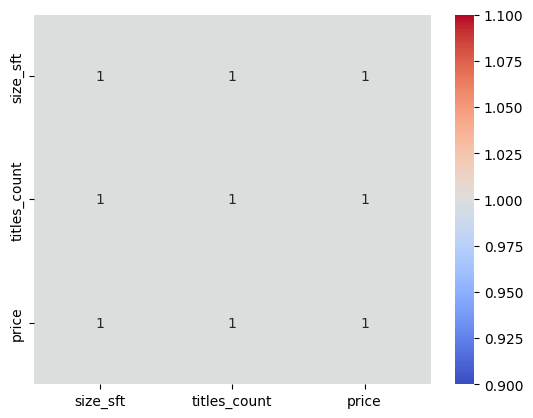

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

## Removing highly correlated features (>0.9))

In [10]:
upper = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column]>0.9)]

print("Highly correlated Featured to Drop:", to_drop)

Highly correlated Featured to Drop: ['titles_count', 'price']


## Chi-Square Test

In [13]:
import pandas as pd

x = pd.DataFrame({
    'gender':[0,1,0,1,1], # 0-F 1-M
    'married':[1,1,0,0,1], # 1-Married 0-Not Married
    'income':[20000,40000,50000,30000,60000]
})

y=[0,1,1,0,1]

x

,gender,married,income
0,0,1,20000
1,1,1,40000
2,0,0,50000
3,1,0,30000
4,1,1,60000


In [ ]:
# Chi-Square Requires Non-Negative values

from sklearn.feature_selection import chi2,SelectKBest
# from sklearn.feature_extraction import SelectKBest
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(x)

selector = SelectKBest(score_func=chi2,k=2)
X_new = selector.fit_transform(X_scaled,y)

selected_features= X.columns[selector.get_support()]

print("Selected Features: ", selected_features ) 


Selected Features:  Index(['married', 'income'], dtype='object')
